## About

This notebook is used to merge all the datasets together:
- stats dataset
- speed dataset
- bandwidth dataset
- economic dataset

The datasets are merged based on year and country code.

<h3>Outline</h3>
<ol style ="list-style-type: none;">
    <li><a href="#setting-up-environment">1. Setting up environment</a></li>
    <li><a href="#changing-granularity-of-stats-dataset">2. Changing granularity of stats dataset</a></li>
    <li><a href="#merging">3. Merging</a>
        <ol style="list-style-type: none;">
            <li><a href="#retrieving-country-codes">3.1. Retrieving country codes</a></li>
            <li><a href="#speed-dataset">3.2. Speed dataset</a>
                <ol style="list-style-type: none;">
                    <li><a href="#speed-data-transformation">I. Speed data transformation</a></li>
                    <li><a href="#speed-dataset-merging">II. Speed dataset merging</a></li>
                </ol>
            </li>
            <li><a href="#bandwidth-dataset">3.3. Bandwidth dataset</a>
                <ol style="list-style-type: none;">
                    <li><a href="#bandwidth-transformation">I. Bandwidth transformation</a></li>
                    <li><a href="#bandwidth-merging">II. Bandwidth merging</a></li>
                </ol>
            </li>
        </ol>
    </li>
    <li><a href="#economic-dataset">4. Economic dataset</a></li>
</ol>

## Setting up environment

In [ ]:
# Import libraries
import pandas as pd
import requests
import re
from fuzzywuzzy import process
import json
import pycountry
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
# Read files
stats_data = pd.read_csv(
    r"C:\Users\gebruikerr\OneDrive\Desktop\country_resource_stats(in).csv"
)
bandwidth = pd.read_excel("bandwidth-worldbank.xlsx")
speed = pd.read_csv("speed-data-okla.csv")

Given that the file of RIPE NCC stats data is too large it was not possible to store it in the repository. It can be found in the project sumbission file. However, all the relevant data extracted from it for modelling and the website can be found in (1) all_data.json (scaled) and (2) website_data.json (unscaled).

## Changing granularity of stats dataset 

In [39]:
stats_data = stats_data.drop(columns=["Unnamed: 0", "starttime", "endtime"])

In [40]:
# Add year and group by year
stats_data["statsdate"] = pd.to_datetime(stats_data["statsdate"])
stats_data["year"] = stats_data["statsdate"].dt.year
stats_data_yearly = stats_data.drop(columns="statsdate")
stats_data_yearly = (
    stats_data_yearly.groupby(["year", "country_code"]).sum().reset_index()
)

## Merging

### Retrieving country codes

In [41]:
# ISO 3166 country codes provided from RIPE
country_list_url = "https://ftp.ripe.net/iso3166-countrycodes.txt"
response = requests.get(country_list_url)

# Check if request was successful and read data
if response.status_code == 200:
    country_list_data = response.text
else:
    print("error while fetching the data")

# Process the text data to retrieve only country codes
country_list_data = [
    re.split(r"\t+|\s{2,}", line) for line in country_list_data.split("\n")
]

country_codes = {}

# Save the country names with country codes
for entry in country_list_data:
    if len(entry) <= 1:
        continue
    if len(entry[1]) > 1:
        country_code = entry[1].lower()
        country_code_3 = entry[2].lower()
    else:
        country_code = None
        country_code_3 = None
    if entry[0].lower() not in country_codes:
        country_codes[entry[0].lower()] = (country_code, country_code_3)

In [42]:
def get_country_code(country_name, country_dict, code_type="2"):
    """
    Counry code fuzzy matching to handle spelling differences etc.
    Return country code with the highest score

    country_name (str)

    country_dict (dict):
        Dictionary with country names and country codes

    code_type (str):
        Determines whether to return 2 or 3 letter code
    """

    match, score = process.extractOne(country_name, country_dict.keys())
    country_code_2, country_code_3 = country_dict[match]

    if code_type == "2":
        return country_code_2
    elif code_type == "3":
        return country_code_3
    else:
        return None

In [43]:
def get_iso2_from_iso3(country_code, country_dict):
    """
    Retrieve ISO 2 country code based on ISO 3

    county_code (str):
        3 letter iso country code

    country_dict (dict):
        Dictionary with country names and codes
    """
    for country, codes in country_dict.items():
        country_code_2, country_code_3 = codes
        if country_code_3 == country_code:
            return country_code_2

    return None

### Speed dataset

#### Speed data transformation

In [44]:
# Transform from wide format to long format
speed_data_melted = speed.melt(
    id_vars=["country", "major_area", "region"],
    var_name="year",
    value_name="speed (mgps)",
)
speed_data_melted["year"] = [year[4:] for year in speed_data_melted["year"]]
speed_data_melted["year"] = pd.to_numeric(speed_data_melted["year"])
speed_data_melted = speed_data_melted[["country", "year", "speed (mgps)"]]

In [45]:
# Perform fuzzy matching to map country codes
speed_data_melted["country"] = speed_data_melted["country"].str.lower()
speed_data_melted["country_code"] = speed_data_melted["country"].apply(
    lambda x: get_country_code(x, country_codes)
)

In [46]:
# Check if countries are correctly matched - fuzzy matching agains dictionary mapping
mismatched_codes = speed_data_melted[
    ~speed_data_melted["country"]
    .map(lambda country: country_codes.get(country.lower(), (None, None))[0])
    .eq(speed_data_melted["country_code"])
]
mismatched_codes = mismatched_codes[["country", "country_code"]].drop_duplicates()
# Manually inspect the country codes
print("Incorrectly matched codes:")
print(mismatched_codes)

Incorrectly matched codes:
                    country country_code
21                  bolivia           bo
22   bosnia and herzegovina           ba
38                  croatia           hr
40                  curaçao           cw
43            côte d'ivoire           ci
48                 dr congo           cg
49               east timor           tl
72          hong kong (sar)           hk
77                     iran           ir
88                   kosovo           ls
91                     laos           bb
100             macau (sar)           mo
112                 moldova           md
118         myanmar (burma)           mm
121             netherlands           nl
126         north macedonia           mk
142                  russia           ru
158             south korea           kp
163               swaziland           th
166                   syria           sy
167                  taiwan           tw
169                tanzania           tz
175                 türkiye   

After manual inspection the following countries and codes were identified to be mismatched (country, matched code, correct code):
- brunei, None, bn
- dr congo, cg, cd
- east timor, tl, tl/tp (east timor belongs to timor-leste, not sure if Ripe recognises them as two different countries)
- kosovo, ls, not included in ripe country codes
- laos, bb, la
- macu (sar), mo
- micronesia, None, fm
- palestine, None, ps
- south korea, kp, kr
- swaziland, th, sz
- united kingdom, nl, uk

In [47]:
# Check for not matched countries
unknown = speed_data_melted[speed_data_melted["country_code"].isna()]
print(unknown["country"].drop_duplicates().sort_values())

25                 brunei
47     dominican republic
67              guatemala
87                  kenya
111            micronesia
130             palestine
Name: country, dtype: object


Unmatched countries with the respected code:
- brunei, bn
- dominican republic, do
- guatemala, gt
- kenya, ke
- micronesia,fm
- palestine, ps

In [48]:
# Manually replace the mismatched and unknown country codes
speed_country_mapping = {
    "brunei": "bn",
    "dr congo": "cd",
    "east timor": "tl",
    "kosovo": None,
    "laos": "la",
    "micronesia": "fm",
    "palestine": "ps",
    "south korea": "kr",
    "swaziland": "sz",
    "united kingdom": "uk",
    "dominican republic": "do",
    "guatemala": "gt",
    "kenya": "ke",
}
speed_data_melted["country_code"] = speed_data_melted.apply(
    lambda row: speed_country_mapping.get(row["country"], row["country_code"]), axis=1
)

#### Speed dataset merging

The merging is done through left join. Keeping all of the entries of stats dataset and retrieving all the entries of speed data that are matched.

In [49]:
stats_speed = stats_data_yearly.merge(
    speed_data_melted,
    left_on=["year", "country_code"],
    right_on=["year", "country_code"],
    how="left",
)

### Bandwidth dataset

#### Bandwidth transformation

In [50]:
# Inlcude only bandiwdth per user
bandwidth_user = bandwidth[
    bandwidth["Indicator"] == "International bandwidth per Internet user (kbit/s)"
]

In [51]:
# Transform from wide format to long format
bandwidth_user_melted = bandwidth_user.melt(
    id_vars=[
        "Economy ISO3",
        "Economy Name",
        "Indicator ID",
        "Indicator",
        "Attribute 1",
        "Attribute 2",
        "Attribute 3",
        "Partner",
    ],
    var_name="year",
    value_name="bandwidth (kbit/s)",
)
# Include only important information and ensure good formatting
bandwidth_user_melted = bandwidth_user_melted.dropna(subset="bandwidth (kbit/s)")
bandwidth_user_melted = bandwidth_user_melted.drop(
    columns=[
        "Indicator ID",
        "Indicator",
        "Attribute 1",
        "Attribute 2",
        "Attribute 3",
        "Partner",
    ]
)
bandwidth_user_melted["Economy ISO3"] = bandwidth_user_melted["Economy ISO3"].apply(
    lambda x: x.lower()
)
bandwidth_user_melted["Economy Name"] = bandwidth_user_melted["Economy Name"].apply(
    lambda x: x.lower()
)
bandwidth_user_melted["year"] = pd.to_numeric(bandwidth_user_melted["year"])

In [52]:
# Retrieve iso 2 country codes based on iso 3
bandwidth_user_melted["Economy ISO2"] = bandwidth_user_melted["Economy ISO3"].apply(
    lambda iso3: get_iso2_from_iso3(iso3, country_codes)
)
# Perform fuzzy matching on country name and check for mismatches
mismatched_codes_bw = bandwidth_user_melted[
    ~bandwidth_user_melted["Economy Name"]
    .apply(lambda x: get_country_code(x, country_codes))
    .eq(bandwidth_user_melted["Economy ISO2"])
]
mismatched_codes_bw = mismatched_codes_bw[
    ["Economy Name", "Economy ISO2"]
].drop_duplicates()
print("Incorrectly matched codes:")
print(mismatched_codes_bw)

Incorrectly matched codes:
             Economy Name Economy ISO2
35       congo, dem. rep.           cd
61         united kingdom         None
72   hong kong sar, china           hk
90        kyrgyz republic           kg
107      macao sar, china           mo
162       slovak republic           sk
338    west bank and gaza         None


After manually inspecting the codes the following were mismatched (country name, matched code, correct code):
- united kingdom, None, uk
- west bank and gaza, None, ps

In [53]:
# Identify countries without a match
unknown_codes_bw = bandwidth_user_melted[bandwidth_user_melted["Economy ISO2"].isna()]
unknown_codes_bw = unknown_codes_bw[["Economy Name", "Economy ISO2"]].drop_duplicates()
print("Unmatched countries:")
print(unknown_codes_bw)

Unmatched countries:
              Economy Name Economy ISO2
25       brunei darussalam         None
48      dominican republic         None
59   micronesia, fed. sts.         None
61          united kingdom         None
70               guatemala         None
89                   kenya         None
94             korea, rep.         None
338     west bank and gaza         None


Unmatched countries with respected code:
- brunei darussalam, bn
- dominican republic, do
- micronesia, fed. sts., fm
- united kingdom, uk
- guatemala, gt
- kenya, ke
- korea, rep., kr
- west bank and gaza, ps

In [54]:
# Manually replace the mismatched and unknown country codes
bandwidth_country_mapping = {
    "brunei darussalam": "bn",
    "dominican republic": "do",
    "micronesia, fed. sts.": "fm",
    "west bank and gaza": "ps",
    "united kingdom": "uk",
    "guatemala": "gt",
    "kenya": "ke",
    "korea, rep.": "kr",
}
bandwidth_user_melted["Economy ISO2"] = bandwidth_user_melted.apply(
    lambda row: bandwidth_country_mapping.get(row["Economy Name"], row["Economy ISO2"]),
    axis=1,
)

#### Bandwidth merging

In [55]:
internet_dataset = stats_speed.merge(
    bandwidth_user_melted,
    left_on=["year", "country_code"],
    right_on=["year", "Economy ISO2"],
    how="left",
)

In [56]:
display(internet_dataset.head())

,year,country_code,v4_prefixes_ris,v6_prefixes_ris,asns_ris,v4_prefixes_stats,v6_prefixes_stats,asns_stats,country,speed (mgps),Economy ISO3,Economy Name,bandwidth (kbit/s),Economy ISO2
0,2015,ad,12953.0,364.0,364.0,-364,-364,364,NaN,NaN,and,andorra,103068.7,ad
1,2015,ae,224073.5,7590.0,18013.5,-365,-365,27051,NaN,NaN,are,united arab emirates,196513.3,ae
2,2015,af,91339.5,1074.0,12448.5,-364,-364,16818,NaN,NaN,afg,afghanistan,13392.9,af
3,2015,ag,75513.0,0.0,1060.0,-364,-364,1820,NaN,NaN,atg,antigua and barbuda,79418.0,ag
4,2015,ai,2517.0,364.0,728.0,-364,-364,1092,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
print("Unique Country Names in internet Dataset:")
print(internet_dataset["country_code"].unique())

Unique Country Names in internet Dataset:
['ad' 'ae' 'af' 'ag' 'ai' 'al' 'am' 'ao' 'ar' 'as' 'at' 'au' 'aw' 'ax'
 'az' 'ba' 'bb' 'bd' 'be' 'bf' 'bg' 'bh' 'bi' 'bj' 'bl' 'bm' 'bo' 'bq'
 'br' 'bs' 'bt' 'bw' 'by' 'bz' 'ca' 'cd' 'cf' 'cg' 'ch' 'ci' 'ck' 'cl'
 'cm' 'cn' 'co' 'cr' 'cu' 'cv' 'cw' 'cy' 'cz' 'de' 'dj' 'dk' 'dm' 'dz'
 'ec' 'ee' 'eg' 'er' 'es' 'et' 'fi' 'fj' 'fo' 'fr' 'ga' 'gd' 'ge' 'gf'
 'gg' 'gh' 'gi' 'gl' 'gm' 'gn' 'gp' 'gq' 'gr' 'gu' 'gw' 'gy' 'hk' 'hn'
 'hr' 'ht' 'hu' 'id' 'ie' 'il' 'im' 'in' 'io' 'iq' 'ir' 'is' 'it' 'je'
 'jm' 'jo' 'jp' 'kg' 'kh' 'ki' 'km' 'kn' 'kp' 'kw' 'ky' 'kz' 'la' 'lb'
 'lc' 'li' 'lk' 'lr' 'ls' 'lt' 'lu' 'lv' 'ly' 'ma' 'mc' 'md' 'me' 'mf'
 'mg' 'mh' 'mk' 'ml' 'mm' 'mn' 'mo' 'mp' 'mq' 'mr' 'ms' 'mt' 'mu' 'mv'
 'mw' 'mx' 'my' 'mz' 'na' 'nc' 'ne' 'nf' 'ng' 'ni' 'nl' 'no' 'np' 'nr'
 'nu' 'nz' 'om' 'pa' 'pe' 'pf' 'pg' 'ph' 'pk' 'pl' 'pm' 'pr' 'pt' 'pw'
 'py' 'qa' 're' 'ro' 'rs' 'ru' 'rw' 'sa' 'sb' 'sc' 'sd' 'se' 'sg' 'si'
 'sk' 'sl' 'sm' 'sn' 'so' 'sr' 'ss'

### Economic dataset

In [59]:
economic = pd.read_csv("economic_index_sorted.csv")

In [60]:
display(economic.head())

,Country Name,Year,Foreign Investment,GNI per Capita,Unemployment Rate,Labor Force participation rate,Economic Index
0,Qatar,2013,0.295509,0.793888,0.004836,0.976958,0.620919
1,Qatar,2014,0.297313,0.758071,0.002687,0.985083,0.605246
2,Qatar,2012,0.296695,0.762014,0.010210,0.976489,0.603933
3,Qatar,2011,0.297215,0.687834,0.012359,0.979822,0.567131
4,Norway,2013,0.295003,0.859854,0.089334,0.610157,0.563592


In [61]:
print("Unique Country Names in Economic Dataset:")
print(economic["Country Name"].unique())

Unique Country Names in Economic Dataset:
['Qatar' 'Norway' 'Switzerland' 'Iceland' 'Luxembourg' 'Ireland' 'Denmark'
 'Netherlands' 'United Arab Emirates' 'Kuwait' 'Sweden' 'Israel' 'Germany'
 'Austria' 'United Kingdom' 'Finland' 'Belgium' 'Bahrain' 'France' 'Malta'
 'Cyprus' 'Saudi Arabia' 'Oman' 'Slovenia' 'Czechia' 'Estonia' 'Italy'
 'Spain' 'Lithuania' 'Portugal' 'Kazakhstan' 'Slovak Republic' 'Poland'
 'Moldova' 'Latvia' 'Hungary' 'Greece' 'Russian Federation'
 'Kyrgyz Republic' 'Belarus' 'Bulgaria' 'Croatia' 'Azerbaijan' 'Romania'
 'Serbia' 'Albania' 'Georgia' 'Turkiye' 'Uzbekistan' 'Ukraine' 'Armenia'
 'Lebanon' 'Bosnia and Herzegovina' 'Montenegro' 'North Macedonia'
 'Tajikistan' 'Syrian Arab Republic' 'Iraq' 'Iran, Islamic Rep.'
 'Yemen, Rep.' 'West Bank and Gaza' 'Jordan' 'Andorra' 'Gibraltar'
 'Greenland' 'Isle of Man' 'Liechtenstein' 'Monaco' 'San Marino'
 'Turkmenistan']


Here we convert country name to country code for econ data

In [62]:
# Load the economic dataset
economic_df = economic  # assuming 'economic' is already defined

# Manual fixes for country names not recognized by pycountry
manual_country_map = {
    "Turkiye": "tr",  # Turkey
    "Iran, Islamic Rep.": "ir",  # Iran
    "West Bank and Gaza": "ps",
    "Yemen, Rep.": "ye",  # Palestine
}


# Function to convert country name to ISO2 code
def get_iso2(country_name):
    # First check manual overrides
    if country_name in manual_country_map:
        return manual_country_map[country_name]
    # Then try pycountry
    try:
        return pycountry.countries.lookup(country_name).alpha_2.lower()
    except LookupError:
        return None


# Apply conversion
economic_df["country_code"] = economic_df["Country Name"].apply(get_iso2)

# Identify missing country mappings
missing_countries = economic_df[economic_df["country_code"].isna()][
    "Country Name"
].unique()

# Print missing country names
print("Countries not mapped:", missing_countries)

Countries not mapped: []


Merging and economic data

In [63]:
# Load both datasets
economic_df = economic
internet_df = internet_dataset

# Ensure both datasets have the correct column names
economic_df = economic_df.rename(
    columns={"country_code": "country_code", "Year": "year"}
)
internet_df = internet_df.rename(
    columns={"country_code": "country_code", "year": "year"}
)

# Merge the datasets on 'country_code' and 'year'
merged_df = pd.merge(economic_df, internet_df, on=["country_code", "year"], how="inner")

# Drop rows with missing values in merged columns (if any)
merged_df = merged_df.dropna(subset=["country_code", "year"])

# Remove unwanted columns
# Cleaning the df
columns_to_remove = [
    "country_code",
    "country",
    "Economy ISO3",
    "Economy Name",
    "Economy ISO2",
]
merged_df = merged_df.drop(columns=columns_to_remove)

display(merged_df)

,Country Name,year,Foreign Investment,GNI per Capita,Unemployment Rate,Labor Force participation rate,Economic Index,v4_prefixes_ris,v6_prefixes_ris,asns_ris,v4_prefixes_stats,v6_prefixes_stats,asns_stats,speed (mgps),bandwidth (kbit/s)
0,Qatar,2015,0.297342,0.658917,0.001881,0.994577,0.557732,106031.0,9118.5,3442.0,-364,-364,4688,NaN,69668.3
1,Qatar,2023,0.295860,0.651195,0.000806,0.999550,0.554932,129173.0,118954.0,4515.0,-339,-339,6658,153.89,NaN
2,Norway,2023,0.306596,0.844081,0.093283,0.597096,0.553463,561217.5,130747.0,95169.0,-351,-351,132916,109.59,NaN
3,Switzerland,2022,0.285778,0.783044,0.108060,0.622858,0.523060,1374139.5,762487.5,263315.5,-365,-365,372696,122.76,NaN
4,Norway,2022,0.310100,0.774337,0.084121,0.606842,0.522723,555407.5,121340.5,95761.0,-352,-352,135991,100.89,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607,Turkmenistan,2019,NaN,0.051672,0.105938,0.282775,NaN,3098.0,0.0,1510.0,-321,-321,2367,2.12,NaN
608,Turkmenistan,2020,NaN,0.054054,0.118243,0.260201,NaN,4116.0,2.0,1650.0,-330,-330,2310,3.56,18803.3
609,Turkmenistan,2021,NaN,0.057833,0.117114,0.264183,NaN,4736.0,340.0,1700.0,-340,-340,2356,4.49,27217.6
610,Turkmenistan,2022,NaN,0.062598,0.107711,0.283748,NaN,6075.0,338.0,1690.0,-338,-338,2028,2.18,NaN


In [64]:
import os

# Define the path to your Desktop (adjust if necessary)
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop", "merged_data.json")

# Save the merged DataFrame as a JSON file on the Desktop
merged_df.to_json(desktop_path, orient="records", lines=True)

print(f"Merged DataFrame saved as 'merged_data.json' on your Desktop: {desktop_path}")

Merged DataFrame saved as 'merged_data.json' on your Desktop: C:\Users\gebruikerr\Desktop\merged_data.json


Correlation Map

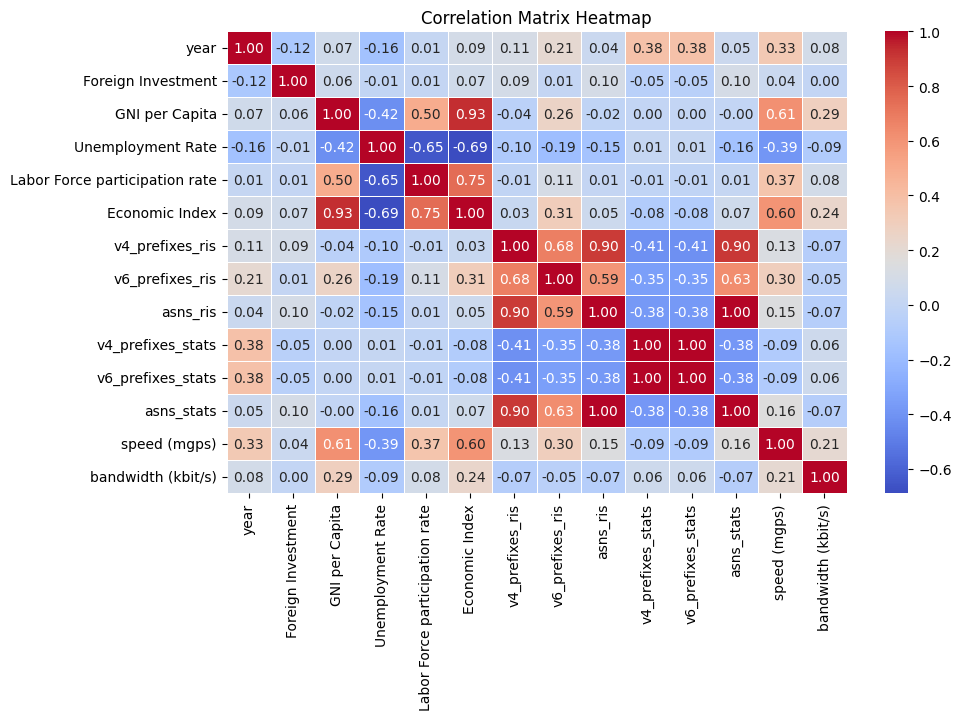

In [66]:
# Select only numeric columns
# Exclude countries
numeric_df = merged_df.select_dtypes(include=["number"])

# Compute the correlation matrix
correlation_matrix = numeric_df.corr()

# Visualizing the correlation matrix with a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [67]:
csv_path = "economic_index_sorted.csv"
df1 = pd.read_csv(csv_path)

In [68]:
display(df1)

,Country Name,Year,Foreign Investment,GNI per Capita,Unemployment Rate,Labor Force participation rate,Economic Index
0,Qatar,2013,0.295509,0.793888,0.004836,0.976958,0.620919
1,Qatar,2014,0.297313,0.758071,0.002687,0.985083,0.605246
2,Qatar,2012,0.296695,0.762014,0.010210,0.976489,0.603933
3,Qatar,2011,0.297215,0.687834,0.012359,0.979822,0.567131
4,Norway,2013,0.295003,0.859854,0.089334,0.610157,0.563592
...,...,...,...,...,...,...,...
1675,Turkmenistan,2019,NaN,0.051672,0.105938,0.282775,NaN
1676,Turkmenistan,2020,NaN,0.054054,0.118243,0.260201,NaN
1677,Turkmenistan,2021,NaN,0.057833,0.117114,0.264183,NaN
1678,Turkmenistan,2022,NaN,0.062598,0.107711,0.283748,NaN


In [ ]:
with open("all_data.json") as f:
    data = json.load(f)

df = pd.DataFrame(data)
display(df)

,Country Name,Year,Foreign Investment,GDP per Capita,Unemployment Rate,Labor Force participation rate,Economic Index_x,v4_prefixes_ris,v6_prefixes_ris,asns_ris,...,v6_prefixes_stats,asns_stats,speed (mgps),bandwidth (kbit/s),Income group,imputed speed,imputed bandwidth,non_imputed_internet_index,imputed_internet_index,Economic Index_y
0,qatar,2022,0.296388,0.345357,0.000806,1.000000,0.402156,0.008931,0.055823,0.002571,...,0.382979,0.002623,0.352037,0.030656,High income,0.352037,0.030656,0.152325,0.152325,0.520737
1,qatar,2023,0.295860,0.312189,0.000806,0.999550,0.385429,0.009345,0.068468,0.002371,...,0.574468,0.002769,0.630353,NaN,High income,0.630353,0.068537,NaN,0.241347,0.554932
2,luxembourg,2021,0.346346,0.520874,0.146991,0.529915,0.371657,0.025711,0.031610,0.015618,...,0.319149,0.017734,0.710388,NaN,High income,0.710388,0.088587,NaN,0.190993,0.470416
3,qatar,2018,0.294219,0.276485,0.000269,0.998703,0.367351,0.007602,0.002526,0.001653,...,0.255319,0.002178,0.127383,0.012695,High income,0.127383,0.012695,0.083084,0.083084,0.488905
4,qatar,2021,0.295267,0.279262,0.001075,0.978165,0.364576,0.008310,0.041304,0.002370,...,0.404255,0.002479,0.446277,0.029791,High income,0.446277,0.029791,0.167380,0.167380,0.499364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,turkmenistan,2019,NaN,0.025390,0.105938,0.282775,NaN,0.000067,0.000000,0.000673,...,0.957447,0.000894,0.000000,NaN,Upper middle income,0.000000,0.009082,NaN,0.240701,NaN
590,turkmenistan,2020,NaN,0.025174,0.118243,0.260201,NaN,0.000142,0.000001,0.000752,...,0.765957,0.000869,0.005981,0.002070,Upper middle income,0.005981,0.002070,0.192716,0.192716,NaN
591,turkmenistan,2021,NaN,0.026962,0.117114,0.264183,NaN,0.000188,0.000196,0.000780,...,0.553191,0.000889,0.009843,0.003088,Upper middle income,0.009843,0.003088,0.140171,0.140171,NaN
592,turkmenistan,2022,NaN,0.031272,0.107711,0.283748,NaN,0.000286,0.000195,0.000774,...,0.595745,0.000746,0.000249,NaN,Upper middle income,0.000249,0.009089,NaN,0.150354,NaN


In [71]:
# Sort the DataFrame by 'GNI econ indec' in descending order and show the top 5 rows
top_gni = df.sort_values(by="Economic Index_y", ascending=False).head(5)
display(top_gni)

,Country Name,Year,Foreign Investment,GDP per Capita,Unemployment Rate,Labor Force participation rate,Economic Index_x,v4_prefixes_ris,v6_prefixes_ris,asns_ris,...,v6_prefixes_stats,asns_stats,speed (mgps),bandwidth (kbit/s),Income group,imputed speed,imputed bandwidth,non_imputed_internet_index,imputed_internet_index,Economic Index_y
5,qatar,2015,0.297342,0.268474,0.001881,0.994577,0.362510,0.007642,0.005248,0.001765,...,0.042553,0.001908,NaN,0.008223,High income,0.147355,0.008223,NaN,0.032156,0.557732
1,qatar,2023,0.295860,0.312189,0.000806,0.999550,0.385429,0.009345,0.068468,0.002371,...,0.574468,0.002769,0.630353,NaN,High income,0.630353,0.068537,NaN,0.241347,0.554932
30,norway,2023,0.306596,0.342329,0.093283,0.597096,0.302587,0.041138,0.075255,0.053609,...,0.319149,0.057938,0.446360,NaN,High income,0.446360,0.037994,NaN,0.168824,0.553463
23,switzerland,2022,0.285778,0.363077,0.108060,0.622858,0.313076,0.100960,0.438873,0.148647,...,0.021277,0.162710,0.501059,NaN,High income,0.501059,0.045278,NaN,0.180010,0.523060
10,norway,2022,0.310100,0.423725,0.084121,0.606842,0.347417,0.040711,0.069841,0.053944,...,0.297872,0.059281,0.410226,NaN,High income,0.410226,0.033838,NaN,0.157948,0.522723


In [76]:
# Data merging for missing data
# Load JSON
with open("missing_data.json", "r") as f:
    missing_data = pd.json_normalize(json.load(f))

# Load CSV
economic_data = pd.read_csv("economic_data.csv")

In [77]:
economic_data.rename(columns={"Year": "year"}, inplace=True)
manual_country_map = {
    "United Kingdom": "gb",
    "Turkiye": "tr",
    "West Bank and Gaza": "ps",
    "Iran, Islamic Rep.": "ir",
}

# Add ISO2 codes to economic_data
economic_data["country_code"] = economic_data["Country Name"].map(manual_country_map)

In [78]:
# Filter missing_data to only the selected countries
target_countries = ["gb", "tr", "ps", "ir"]
missing_data_filtered = missing_data[
    missing_data["country_code"].isin(target_countries)
]

# Filter economic_data to the same countries
economic_data_filtered = economic_data[
    economic_data["country_code"].isin(target_countries)
]

In [80]:
merged = pd.merge(
    missing_data_filtered,
    economic_data_filtered,
    on=[
        "country_code",
        "year",
    ],  # or just "country_code" if "Year" isn't present in both
    how="inner",  # or "left"/"right"/"outer" depending on your goal
)

In [91]:
display(merged())

TypeError: 'DataFrame' object is not callable

In [ ]:
merged.to_json("missing_data.json", orient="records", indent=2)

print("'missing_data.json' has been updated with the merged data.")

✅ 'missing_data.json' has been updated with the merged data.


Merging missing data to all data

In [ ]:
# Load both JSON files
import pandas as pd

# Load JSONs
df_all = pd.read_json("all_data.json")
df_missing = pd.read_json("missing_data.json")

# Standardize year column
df_all = df_all.rename(columns={"Year": "year"})
df_missing = df_missing.rename(columns={"Year": "year"})

# Drop old economic index variants in df_all
df_all = df_all.drop(columns=["Economic Index_x"], errors="ignore")

# Rename missing data economic index to unify column name
df_missing = df_missing.rename(columns={"GNI Economic Index": "Economic Index_y"})

# Merge
df_combined = pd.concat([df_all, df_missing], ignore_index=True)

# Save merged data
df_combined.to_json("all_data.json", orient="records", indent=2)

print("Data merged with unified 'year' and 'Economic Index' columns.")

✅ Data merged with unified 'year' and 'Economic Index' columns.


In [ ]:
# Load JSON
df = pd.read_json("all_data.json")

# Columns to drop
cols_to_drop = [
    "country_code",
    "Country Code",
    "GDP",
    "GNI",
    "GNI per Capita",
    "GINI Index",
]

# Drop the specified columns if they exist
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Save back to JSON
df.to_json("all_data.json", orient="records", indent=2)

print("Specified columns dropped and saved back to all_data.json.")

✅ Specified columns dropped and saved back to all_data.json.


In [ ]:
df_all = pd.read_json("all_data.json")
df_missing = pd.read_json("missing_data.json")

# Make sure the column names align (especially for index column)
df_missing = df_missing.rename(columns={"GNI Economic Index": "Economic Index"})

# Concatenate rows
df_combined = pd.concat([df_all, df_missing], ignore_index=True)

# Save back to all_data.json
df_combined.to_json("all_data.json", orient="records", indent=2)

print("'missing_data.json' rows successfully added to 'all_data.json'.")

✅ 'missing_data.json' rows successfully added to 'all_data.json'.


In [ ]:
# Load the datasets
df_all = pd.read_json("all_data.json")
df_missing = pd.read_json("missing_data.json")

# Rename column in df_missing
df_missing = df_missing.rename(columns={"GNI Economic Index": "Economic Index"})

# Concatenate the two datasets
df_combined = pd.concat([df_all, df_missing], ignore_index=True)

# Now drop unwanted columns, but **do not drop 'Economic Index'**
cols_to_drop = [
    "year",
    "GNI per Capita",
    "Foreign Investment_selected",
    "GNI per Capita_selected",
    "Unemployment Rate_selected",
    "Labor Force participation rate_selected",
    "country_code",
    "Country Code",
    "GDP",
    "GNI",
    "GNI per Capita_missing",
    "Foreign Investment_missing",
    "GINI Index",
    "Unemployment Rate_missing",
    "Labor Force participation rate_missing",
]

# If both columns exist, create the new combined column by prioritizing non-null values
df_combined["GNI Economic Index"] = df_combined["GNI Economic Index"].combine_first(
    df_combined["Economic Index"]
)

# Then drop the old 'Economic Index' column
df_combined = df_combined.drop(columns=["Economic Index"])

df_combined = df_combined.drop(
    columns=[col for col in cols_to_drop if col in df_combined.columns]
)
display(df_combined)
# Save back to JSON
# df_combined.to_json("all_data.json", orient="records", indent=2)

,Country Name,Year,Foreign Investment,GDP per Capita,Unemployment Rate,Labor Force participation rate,Economic Index_x,v4_prefixes_ris,v6_prefixes_ris,asns_ris,...,v6_prefixes_stats,asns_stats,speed (mgps),bandwidth (kbit/s),Income group,imputed speed,imputed bandwidth,non_imputed_internet_index,imputed_internet_index,GNI Economic Index
0,qatar,2022.0,0.296388,0.345357,0.000806,1.000000,0.402156,0.008931,0.055823,0.002571,...,0.382979,0.002623,0.352037,0.030656,High income,0.352037,0.030656,0.152325,0.152325,0.520737
1,qatar,2023.0,0.295860,0.312189,0.000806,0.999550,0.385429,0.009345,0.068468,0.002371,...,0.574468,0.002769,0.630353,NaN,High income,0.630353,0.068537,NaN,0.241347,0.554932
2,luxembourg,2021.0,0.346346,0.520874,0.146991,0.529915,0.371657,0.025711,0.031610,0.015618,...,0.319149,0.017734,0.710388,NaN,High income,0.710388,0.088587,NaN,0.190993,0.470416
3,qatar,2018.0,0.294219,0.276485,0.000269,0.998703,0.367351,0.007602,0.002526,0.001653,...,0.255319,0.002178,0.127383,0.012695,High income,0.127383,0.012695,0.083084,0.083084,0.488905
4,qatar,2021.0,0.295267,0.279262,0.001075,0.978165,0.364576,0.008310,0.041304,0.002370,...,0.404255,0.002479,0.446277,0.029791,High income,0.446277,0.029791,0.167380,0.167380,0.499364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,West Bank and Gaza,NaN,0.296442,3656.858271,0.678130,0.219846,NaN,0.009585,0.013220,0.006058,...,1.000000,0.015003,0.079325,0.424121,NaN,0.079325,0.424121,0.318414,0.318414,-0.045419
581,West Bank and Gaza,NaN,0.296492,3620.360487,0.687184,0.215036,NaN,0.004345,0.009356,0.003155,...,0.478261,0.007144,0.006640,0.284386,NaN,0.006640,0.284386,0.158944,0.158944,-0.049295
582,West Bank and Gaza,NaN,0.296517,3562.330943,0.702740,0.205091,NaN,0.006880,0.015474,0.008300,...,0.304348,0.011981,0.000000,0.361803,NaN,0.000000,0.361803,0.126641,0.126641,-0.053325
583,West Bank and Gaza,NaN,0.296654,3678.635657,0.706341,0.203560,NaN,0.023791,0.005662,0.013123,...,0.521739,0.023037,0.286432,0.605553,NaN,0.286432,0.605553,0.250135,0.250135,-0.054009


In [113]:
# Load your all_data JSON into a DataFrame (assuming it's already loaded as df_all_data)
# df_all_data = pd.read_json('all_data.json')  # example if you need to load

# List of columns to drop
cols_to_drop = [
    "Economic Index",
    "year",
    "GNI per Capita",
    "Foreign Investment_selected",
    "GNI per Capita_selected",
    "Unemployment Rate_selected",
    "Labor Force participation rate_selected",
    "country_code",
    "Country Code",
    "GDP",
    "GNI",
    "GNI per Capita_missing",
    "Foreign Investment_missing",
    "GINI Index",
    "Unemployment Rate_missing",
    "Labor Force participation rate_missing",
]

# Drop columns if they exist in the dataframe
df_all = df_all.drop(columns=[col for col in cols_to_drop if col in df_all.columns])
display(df_all)
# Save the cleaned DataFrame back to JSON
# df_all_data.to_json('all_data_cleaned.json', orient='records', indent=2)

,Country Name,Year,Foreign Investment,GDP per Capita,Unemployment Rate,Labor Force participation rate,Economic Index_x,v4_prefixes_ris,v6_prefixes_ris,asns_ris,...,v6_prefixes_stats,asns_stats,speed (mgps),bandwidth (kbit/s),Income group,imputed speed,imputed bandwidth,non_imputed_internet_index,imputed_internet_index,GNI Economic Index
0,qatar,2022,0.296388,0.345357,0.000806,1.000000,0.402156,0.008931,0.055823,0.002571,...,0.382979,0.002623,0.352037,0.030656,High income,0.352037,0.030656,0.152325,0.152325,0.520737
1,qatar,2023,0.295860,0.312189,0.000806,0.999550,0.385429,0.009345,0.068468,0.002371,...,0.574468,0.002769,0.630353,NaN,High income,0.630353,0.068537,NaN,0.241347,0.554932
2,luxembourg,2021,0.346346,0.520874,0.146991,0.529915,0.371657,0.025711,0.031610,0.015618,...,0.319149,0.017734,0.710388,NaN,High income,0.710388,0.088587,NaN,0.190993,0.470416
3,qatar,2018,0.294219,0.276485,0.000269,0.998703,0.367351,0.007602,0.002526,0.001653,...,0.255319,0.002178,0.127383,0.012695,High income,0.127383,0.012695,0.083084,0.083084,0.488905
4,qatar,2021,0.295267,0.279262,0.001075,0.978165,0.364576,0.008310,0.041304,0.002370,...,0.404255,0.002479,0.446277,0.029791,High income,0.446277,0.029791,0.167380,0.167380,0.499364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,West Bank and Gaza,2019,0.296442,3656.858271,0.678130,0.219846,NaN,0.009585,0.013220,0.006058,...,1.000000,0.015003,0.079325,0.424121,None,0.079325,0.424121,0.318414,0.318414,NaN
545,West Bank and Gaza,2017,0.296492,3620.360487,0.687184,0.215036,NaN,0.004345,0.009356,0.003155,...,0.478261,0.007144,0.006640,0.284386,None,0.006640,0.284386,0.158944,0.158944,NaN
546,West Bank and Gaza,2018,0.296517,3562.330943,0.702740,0.205091,NaN,0.006880,0.015474,0.008300,...,0.304348,0.011981,0.000000,0.361803,None,0.000000,0.361803,0.126641,0.126641,NaN
547,West Bank and Gaza,2021,0.296654,3678.635657,0.706341,0.203560,NaN,0.023791,0.005662,0.013123,...,0.521739,0.023037,0.286432,0.605553,None,0.286432,0.605553,0.250135,0.250135,NaN
